# 02 — Siamese v2 (FashionCLIP backbone)

Same architecture as the baseline siamese (`SiameseEmbedder` + classifier with
raw cosine + jaccard + geo features). Only change: image projection input goes
from **768-d (vanilla CLIP)** to **512-d (FashionCLIP)**.

Training pairs reused as-is from `artifacts/pairs/{train,val}_pairs.csv`
(already hard-mined against the OLD vanilla-CLIP joint similarity — re-mining
against FashionCLIP could come later if F1 plateaus).

Final cells generate a clustering on the 30k val slice from `items_train`,
write it to `phase2/submissions/val_clusters_v2.csv`, and let you interactively
flip through random multi-item clusters with `Enter` to confirm whether the
groupings make sense.


In [1]:
import sys, os
sys.path.insert(0, '/Users/matouskovar/FIT/adm-sp/src')

REPO_ROOT          = '/Users/matouskovar/FIT/adm-sp'
DATA_DIR           = f'{REPO_ROOT}/data'
ARTIFACTS_DIR      = f'{REPO_ROOT}/artifacts'
PHASE2_DIR         = f'{REPO_ROOT}/phase2'

FASHION_EMB_PATH   = f'{PHASE2_DIR}/embeddings/fashion_clip_image.pt'
TEXT_EMB_PATH      = f'{ARTIFACTS_DIR}/embeddings/text_multilingual.pt'
PIPELINE_PATH      = f'{ARTIFACTS_DIR}/pipelines/preprocessing.pkl'
VOCAB_DIR          = f'{ARTIFACTS_DIR}/vocabularies'
TRAIN_PAIRS_PATH   = f'{ARTIFACTS_DIR}/pairs/train_pairs.csv'
VAL_PAIRS_PATH     = f'{ARTIFACTS_DIR}/pairs/val_pairs.csv'

SIAMESE_V2_PATH    = f'{PHASE2_DIR}/models/siamese_v2.pth'
VAL_SUBMISSION     = f'{PHASE2_DIR}/submissions/val_clusters_v2.csv'

IMAGES_DIR         = '/Users/matouskovar/FIT/images'

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import pickle
import random
from tqdm.auto import tqdm

# Image embedding dim from FashionCLIP
IMG_EMB_DIM  = 512
TEXT_EMB_DIM = 512

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: mps


## 1. Load embeddings, pipeline, vocab

In [2]:
print('Loading FashionCLIP image embeddings...')
clip_embeddings_dict = torch.load(FASHION_EMB_PATH, map_location='cpu', weights_only=False)
sample = next(iter(clip_embeddings_dict.values()))
print(f'  {len(clip_embeddings_dict):,} items, dim={sample.shape[0]}')
assert sample.shape[0] == IMG_EMB_DIM, f'Expected {IMG_EMB_DIM}d FashionCLIP image embeddings, got {sample.shape[0]}d'

print('Loading multilingual text embeddings...')
text_embeddings_dict = torch.load(TEXT_EMB_PATH, map_location='cpu', weights_only=False)
print(f'  {len(text_embeddings_dict):,} items, dim={next(iter(text_embeddings_dict.values())).shape[0]}')

from GlamiDatasetVocabulary import GlamiVocabularyManager
vocab_manager = GlamiVocabularyManager.load_from_dir(VOCAB_DIR)
print(f'Vocab — geo={len(vocab_manager.geo_dict)}, color={len(vocab_manager.color_dict)}, dept={len(vocab_manager.dept_dict)}')

pipeline = pickle.load(open(PIPELINE_PATH, 'rb'))
print('Pipeline loaded.')


Loading FashionCLIP image embeddings...
  1,325,906 items, dim=512
Loading multilingual text embeddings...
  1,325,906 items, dim=512
Vocab — geo=13, color=94, dept=3
Pipeline loaded.


In [3]:
df_train  = pd.read_csv(f'{DATA_DIR}/items_train.csv')
df_phase1 = pd.read_csv(f'{DATA_DIR}/items_phase_1.csv')

X_train = df_train.drop(columns=['label'])
df_train_transformed = pipeline.transform(X_train)
df_train_transformed['label']  = df_train['label'].values
df_train_transformed['itemId'] = df_train['itemId'].values

df_phase1_transformed = pipeline.transform(df_phase1)
df_phase1_transformed['itemId'] = df_phase1['itemId'].values

print(f'Train: {len(df_train_transformed):,}  |  Phase 1: {len(df_phase1_transformed):,}')


Train: 928,234  |  Phase 1: 199,835


## 2. Datasets

In [4]:
class LightweightItemDataset(Dataset):
    """One item -> dict of tensors. Uses precomputed image (512d) + text (512d) embeddings."""
    def __init__(self, df, vocab_manager, image_embeddings_dict, text_embeddings_dict):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab_manager
        self.image_embeddings_dict = image_embeddings_dict
        self.text_embeddings_dict = text_embeddings_dict
        self.id_to_idx = {str(row['itemId']): i for i, row in self.df.iterrows()}

    def __len__(self):
        return len(self.df)

    def _to_multi_hot(self, ids_string, vocab_dict):
        t = torch.zeros(len(vocab_dict), dtype=torch.float32)
        if pd.isna(ids_string) or str(ids_string).strip() == '':
            return t
        for raw_id in str(ids_string).split(','):
            raw_id = raw_id.strip()
            if raw_id in vocab_dict:
                t[vocab_dict[raw_id]] = 1.0
        return t

    def get_item_by_id(self, item_id):
        idx = self.id_to_idx.get(str(item_id))
        return self[idx] if idx is not None else None

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        item_id = str(row['itemId'])

        price  = torch.tensor([row['price_scaled']], dtype=torch.float32)
        geo    = torch.tensor(self.vocab.geo_dict.get(str(row['geo']), 0), dtype=torch.long)
        colors = self._to_multi_hot(row.get('colorTagIdsString', ''), self.vocab.color_dict)
        depts  = self._to_multi_hot(row.get('departmentIds', ''),      self.vocab.dept_dict)

        img_emb = self.image_embeddings_dict.get(item_id, torch.zeros(IMG_EMB_DIM, dtype=torch.float32))
        txt_emb = self.text_embeddings_dict.get(item_id,  torch.zeros(TEXT_EMB_DIM, dtype=torch.float32))
        if img_emb.device.type != 'cpu': img_emb = img_emb.cpu()
        if txt_emb.device.type != 'cpu': txt_emb = txt_emb.cpu()

        img_emb = F.normalize(img_emb, dim=0)
        txt_emb = F.normalize(txt_emb, dim=0)

        return {
            'item_id':         item_id,
            'price':           price,
            'geo':             geo,
            'colors':          colors,
            'departments':     depts,
            'image_embedding': img_emb,
            'text_embedding':  txt_emb,
        }


class FastSiameseDataset(Dataset):
    def __init__(self, pairs_df, item_dataset):
        self.item_dataset = item_dataset
        self.id_to_idx    = item_dataset.id_to_idx
        valid = (pairs_df['item_id_1'].astype(str).isin(self.id_to_idx) &
                 pairs_df['item_id_2'].astype(str).isin(self.id_to_idx))
        self.pairs = pairs_df[valid].reset_index(drop=True)
        print(f'Valid pairs: {len(self.pairs):,}  (filtered {(~valid).sum():,})')

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        row = self.pairs.iloc[idx]
        i1 = self.id_to_idx[str(int(row['item_id_1']))]
        i2 = self.id_to_idx[str(int(row['item_id_2']))]
        return self.item_dataset[i1], self.item_dataset[i2], torch.tensor(row['is_duplicate'], dtype=torch.float32)


In [5]:
# Train + val pairs
train_pairs_full = pd.read_csv(TRAIN_PAIRS_PATH)
val_pairs_full   = pd.read_csv(VAL_PAIRS_PATH)
print(f'Train pairs: {len(train_pairs_full):,}  |  pos rate {train_pairs_full.is_duplicate.mean():.1%}')
print(f'Val pairs:   {len(val_pairs_full):,}    |  pos rate {val_pairs_full.is_duplicate.mean():.1%}')

# Use everything (already pre-balanced when mined). If memory pressure, downsample here.
train_pairs = train_pairs_full.sample(frac=1, random_state=42).reset_index(drop=True)
val_pairs   = val_pairs_full.sample(frac=1, random_state=42).reset_index(drop=True)

print('Building item dataset (uses df_train_transformed for label coverage of both train and val pairs)...')
item_dataset  = LightweightItemDataset(df_train_transformed, vocab_manager,
                                       clip_embeddings_dict, text_embeddings_dict)
train_siamese = FastSiameseDataset(train_pairs, item_dataset)
val_siamese   = FastSiameseDataset(val_pairs,   item_dataset)


Train pairs: 1,500,000  |  pos rate 26.7%
Val pairs:   400,000    |  pos rate 25.0%
Building item dataset (uses df_train_transformed for label coverage of both train and val pairs)...
Valid pairs: 1,500,000  (filtered 0)
Valid pairs: 400,000  (filtered 0)


## 3. Model (image_proj 512 → hidden, otherwise identical to baseline)

In [6]:
class SiameseEmbedder(nn.Module):
    """image (512) + text (512) + price (1) -> output_dim."""
    def __init__(self, img_dim=IMG_EMB_DIM, text_dim=TEXT_EMB_DIM, hidden_dim=256, output_dim=128):
        super().__init__()
        self.image_proj = nn.Sequential(
            nn.Linear(img_dim, hidden_dim),  nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(0.2))
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(0.2))
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2 + 1, hidden_dim), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim))

    def forward(self, image_emb, text_emb, price):
        return self.fusion(torch.cat([self.image_proj(image_emb),
                                       self.text_proj(text_emb),
                                       price], dim=1))


class SiameseNetwork(nn.Module):
    """|emb_diff| + raw image-cos + raw text-cos + dept-jaccard + color-jaccard + geo-match."""
    def __init__(self, n_colors, n_depts, n_geos, output_dim=128):
        super().__init__()
        self.embedder = SiameseEmbedder(output_dim=output_dim)
        self.classifier = nn.Sequential(
            nn.Linear(output_dim + 5, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),             nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1))

    def forward_one(self, item):
        return self.embedder(item['image_embedding'], item['text_embedding'], item['price'])

    @staticmethod
    def _cos(a, b): return (a * b).sum(dim=1, keepdim=True)

    @staticmethod
    def _jac(a, b):
        inter = (a * b).sum(dim=1)
        union = (a + b).clamp(max=1.0).sum(dim=1)
        return (inter / union.clamp(min=1e-6)).unsqueeze(1)

    @staticmethod
    def _geo(g1, g2): return (g1 == g2).float().unsqueeze(1)

    def forward(self, item1, item2):
        e1 = self.forward_one(item1); e2 = self.forward_one(item2)
        x = torch.cat([
            torch.abs(e1 - e2),
            self._cos(item1['image_embedding'], item2['image_embedding']),
            self._cos(item1['text_embedding'],  item2['text_embedding']),
            self._jac(item1['departments'], item2['departments']),
            self._jac(item1['colors'],      item2['colors']),
            self._geo(item1['geo'],         item2['geo']),
        ], dim=1)
        return self.classifier(x).squeeze(1)


In [7]:
def siamese_collate_fn(batch):
    items1, items2, labels = zip(*batch)
    keys = ['image_embedding','text_embedding','price','geo','colors','departments']
    def stack(items): return {k: torch.stack([it[k] for it in items]) for k in keys}
    return stack(items1), stack(items2), torch.stack(list(labels))

BATCH_SIZE = 512
train_loader = DataLoader(train_siamese, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, collate_fn=siamese_collate_fn)
val_loader   = DataLoader(val_siamese,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, collate_fn=siamese_collate_fn)
print(f'Train batches: {len(train_loader):,}  |  Val batches: {len(val_loader):,}')


Train batches: 2,930  |  Val batches: 782


In [8]:
n_colors = len(vocab_manager.color_dict)
n_depts  = len(vocab_manager.dept_dict)
n_geos   = len(vocab_manager.geo_dict)

model = SiameseNetwork(n_colors, n_depts, n_geos, output_dim=128).to(device)
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


Trainable params: 453,633


## 4. Training loop

In [9]:
from sklearn.metrics import f1_score, precision_score, recall_score

def _to_dev(d, dev):
    return {k: v.to(dev) if isinstance(v, torch.Tensor) else v for k, v in d.items()}

def train_epoch(model, loader, opt, crit):
    model.train()
    total, preds, labels = 0.0, [], []
    for it1, it2, lbl in tqdm(loader, desc='Train'):
        it1, it2, lbl = _to_dev(it1, device), _to_dev(it2, device), lbl.to(device)
        opt.zero_grad()
        logits = model(it1, it2)
        loss = crit(logits, lbl)
        loss.backward(); opt.step()
        total += loss.item() * lbl.size(0)
        preds.extend((torch.sigmoid(logits) > 0.5).float().cpu().numpy())
        labels.extend(lbl.cpu().numpy())
    return total / len(loader.dataset), f1_score(labels, preds)

def validate(model, loader, crit):
    model.eval()
    total, preds, labels = 0.0, [], []
    with torch.no_grad():
        for it1, it2, lbl in tqdm(loader, desc='Val'):
            it1, it2, lbl = _to_dev(it1, device), _to_dev(it2, device), lbl.to(device)
            logits = model(it1, it2)
            total += crit(logits, lbl).item() * lbl.size(0)
            preds.extend((torch.sigmoid(logits) > 0.5).float().cpu().numpy())
            labels.extend(lbl.cpu().numpy())
    return (total / len(loader.dataset),
            f1_score(labels, preds),
            precision_score(labels, preds),
            recall_score(labels, preds))


In [10]:
NUM_EPOCHS = 10
LR         = 1e-3

opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', patience=2, factor=0.5)
crit  = nn.BCEWithLogitsLoss()

os.makedirs(os.path.dirname(SIAMESE_V2_PATH), exist_ok=True)

best_f1 = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

for epoch in range(NUM_EPOCHS):
    print(f'\n===== Epoch {epoch + 1}/{NUM_EPOCHS} =====')
    tr_loss, tr_f1                = train_epoch(model, train_loader, opt, crit)
    va_loss, va_f1, va_prec, va_rec = validate(model, val_loader, crit)

    sched.step(va_f1)
    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_f1'].append(tr_f1);     history['val_f1'].append(va_f1)

    print(f'  Train  loss={tr_loss:.4f}  F1={tr_f1:.4f}')
    print(f'  Val    loss={va_loss:.4f}  F1={va_f1:.4f}  P={va_prec:.4f}  R={va_rec:.4f}')

    if va_f1 > best_f1:
        best_f1 = va_f1
        torch.save(model.state_dict(), SIAMESE_V2_PATH)
        print(f'  Saved best to {SIAMESE_V2_PATH}  (F1={va_f1:.4f})')

print(f'\nBest Val F1: {best_f1:.4f}')



===== Epoch 1/10 =====


Train:   0%|          | 0/2930 [00:00<?, ?it/s]

Val:   0%|          | 0/782 [00:00<?, ?it/s]

  Train  loss=0.0712  F1=0.9487
  Val    loss=0.0511  F1=0.9641  P=0.9389  R=0.9906
  Saved best to /Users/matouskovar/FIT/adm-sp/phase2/models/siamese_v2.pth  (F1=0.9641)

===== Epoch 2/10 =====


Train:   0%|          | 0/2930 [00:00<?, ?it/s]

...

Val:   0%|          | 0/782 [00:00<?, ?it/s]

  Train  loss=0.0177  F1=0.9897
  Val    loss=0.0360  F1=0.9813  P=0.9929  R=0.9700

===== Epoch 10/10 =====


Train:   0%|          | 0/2930 [00:00<?, ?it/s]

Val:   0%|          | 0/782 [00:00<?, ?it/s]

  Train  loss=0.0178  F1=0.9896
  Val    loss=0.0280  F1=0.9846  P=0.9886  R=0.9806
  Saved best to /Users/matouskovar/FIT/adm-sp/phase2/models/siamese_v2.pth  (F1=0.9846)

Best Val F1: 0.9846


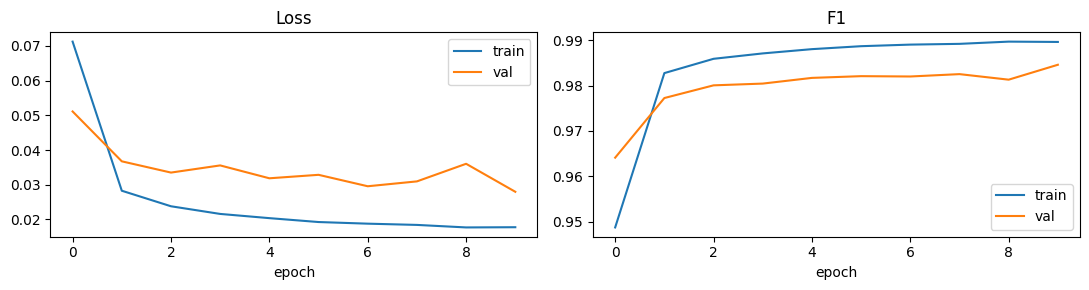

In [11]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))
ax1.plot(history['train_loss'], label='train'); ax1.plot(history['val_loss'], label='val')
ax1.set_title('Loss'); ax1.set_xlabel('epoch'); ax1.legend()
ax2.plot(history['train_f1'],   label='train'); ax2.plot(history['val_f1'],   label='val')
ax2.set_title('F1');   ax2.set_xlabel('epoch'); ax2.legend()
plt.tight_layout(); plt.show()


## 4b. First sanity check — `task_1.csv` (Phase 1 task)

Quick label-free quality probe before we move on to the heavier end-to-end
clustering eval. For each of the 15,000 predefined groups of 5 items, score
the max pair-logit. Auto-calibrate a threshold to ~20% positive rate (matches
the prior seen in the baseline submission), then **compare against the
existing `artifacts/submissions/submission_phase1.txt`** (the F1≈0.97 reference).

**What we're looking for:**
- High agreement (≥90%) → v2 is at least as discriminating on Phase 1
- Sane logit distribution (clear bimodality at the threshold)
- Disagreement cases worth eyeballing (visual cells below)


In [12]:
from itertools import combinations

# Load best v2 weights (in case last-epoch != best-epoch)
model.load_state_dict(torch.load(SIAMESE_V2_PATH, map_location=device, weights_only=True))
model.eval()

# Phase 1 dataset on the same FashionCLIP + multilingual text embeddings
phase1_item_dataset = LightweightItemDataset(
    df_phase1_transformed, vocab_manager,
    image_embeddings_dict=clip_embeddings_dict,
    text_embeddings_dict=text_embeddings_dict,
)
print(f'Phase 1 item dataset: {len(phase1_item_dataset):,} items')

df_task_1 = pd.read_csv(f'{DATA_DIR}/task_1.csv')
print(f'task_1 groups: {len(df_task_1):,}')


Phase 1 item dataset: 199,835 items
task_1 groups: 15,000


In [13]:
@torch.no_grad()
def score_group(model, group_items, item_dataset):
    """Return (max_logit, sigmoid_score, best_pair_ids) over the C(5,2)=10 pairs in the group."""
    feats, ids = [], []
    for iid in group_items:
        f = item_dataset.get_item_by_id(str(iid))
        if f is not None:
            feats.append(f); ids.append(iid)
    if len(feats) < 2:
        return -999.0, 0.0, (None, None)

    max_logit = -999.0
    best_pair = (None, None)
    for (i, f1), (j, f2) in combinations(enumerate(feats), 2):
        b1 = {k: v.unsqueeze(0).to(device) if isinstance(v, torch.Tensor) else v
              for k, v in f1.items() if k != 'item_id'}
        b2 = {k: v.unsqueeze(0).to(device) if isinstance(v, torch.Tensor) else v
              for k, v in f2.items() if k != 'item_id'}
        logit = model(b1, b2).item()
        if logit > max_logit:
            max_logit, best_pair = logit, (ids[i], ids[j])
    return max_logit, float(torch.sigmoid(torch.tensor(max_logit))), best_pair

raw_logits, raw_scores, best_pairs = [], [], []
for _, row in tqdm(df_task_1.iterrows(), total=len(df_task_1), desc='Scoring task_1 groups'):
    items = [row['item1'], row['item2'], row['item3'], row['item4'], row['item5']]
    l, s, p = score_group(model, items, phase1_item_dataset)
    raw_logits.append(l); raw_scores.append(s); best_pairs.append(p)

df_task_1 = df_task_1.copy()
df_task_1['max_logit'] = raw_logits
df_task_1['max_score'] = raw_scores
df_task_1['best_pair'] = best_pairs


Scoring task_1 groups:   0%|          | 0/15000 [00:00<?, ?it/s]

Auto-calibrated threshold: logit=2.425  (sigmoid=0.919)

Prediction distribution:
prediction
0    11999
1     3001
Name: count, dtype: int64
Positive rate: 20.01%  (target ~20%)


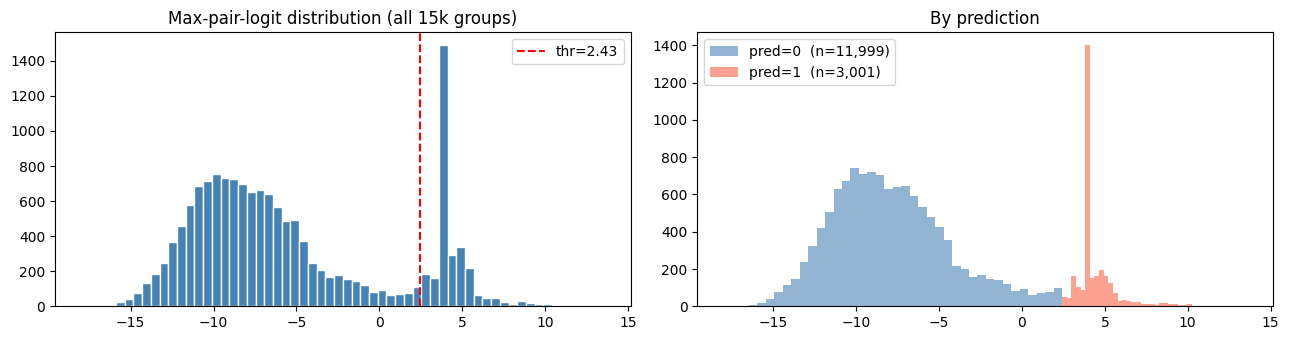

In [14]:
# Auto-calibrate threshold so positive rate matches the baseline prior (~20%)
TARGET_POSITIVE_RATE = 0.20
logits_sorted = sorted(raw_logits, reverse=True)
auto_thr_logit = logits_sorted[int(TARGET_POSITIVE_RATE * len(logits_sorted))]
auto_thr_sig   = float(torch.sigmoid(torch.tensor(auto_thr_logit)))
print(f'Auto-calibrated threshold: logit={auto_thr_logit:.3f}  (sigmoid={auto_thr_sig:.3f})')

df_task_1['prediction'] = (df_task_1['max_logit'] >= auto_thr_logit).astype(int)
print('\nPrediction distribution:')
print(df_task_1['prediction'].value_counts())
print(f'Positive rate: {df_task_1["prediction"].mean():.2%}  (target ~20%)')

# Logit histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].hist(raw_logits, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(auto_thr_logit, color='red', ls='--', label=f'thr={auto_thr_logit:.2f}')
axes[0].set_title('Max-pair-logit distribution (all 15k groups)'); axes[0].legend()

pos = [l for l, p in zip(raw_logits, df_task_1['prediction']) if p == 1]
neg = [l for l, p in zip(raw_logits, df_task_1['prediction']) if p == 0]
axes[1].hist(neg, bins=40, alpha=0.6, color='steelblue', label=f'pred=0  (n={len(neg):,})')
axes[1].hist(pos, bins=40, alpha=0.6, color='tomato',    label=f'pred=1  (n={len(pos):,})')
axes[1].set_title('By prediction'); axes[1].legend()
plt.tight_layout(); plt.show()


In [15]:
# Compare against the existing baseline submission (F1≈0.97 reference)
BASELINE_SUB = f'{ARTIFACTS_DIR}/submissions/submission_phase1.txt'
if os.path.exists(BASELINE_SUB):
    with open(BASELINE_SUB) as f:
        old_preds = np.array([int(line.strip()) for line in f if line.strip()])
    new_preds = df_task_1['prediction'].values

    if len(old_preds) != len(new_preds):
        print(f'⚠️ Length mismatch: old={len(old_preds)}, new={len(new_preds)}. Skipping comparison.')
    else:
        agree   = (old_preds == new_preds).mean()
        both_1  = ((old_preds == 1) & (new_preds == 1)).sum()
        both_0  = ((old_preds == 0) & (new_preds == 0)).sum()
        old_only = ((old_preds == 1) & (new_preds == 0)).sum()
        new_only = ((old_preds == 0) & (new_preds == 1)).sum()

        print(f'Agreement with baseline submission: {agree:.2%}  ({len(old_preds):,} groups)')
        print(f'  Both said positive  : {both_1:>5,}')
        print(f'  Both said negative  : {both_0:>5,}')
        print(f'  Only baseline said + : {old_only:>5,}  (v2 missed)')
        print(f'  Only v2 said +       : {new_only:>5,}  (v2 added)')
        print()
        print(f'Baseline positive rate : {old_preds.mean():.2%}')
        print(f'v2 positive rate       : {new_preds.mean():.2%}')

        # Stash disagreement indices for the visual cell below
        disagree_idx = np.where(old_preds != new_preds)[0]
        print(f'\nDisagreements: {len(disagree_idx):,} groups (will sample 3 for visual review)')
else:
    print(f'⚠️ {BASELINE_SUB} not found — skipping cross-submission comparison.')
    disagree_idx = np.array([], dtype=int)


Agreement with baseline submission: 98.28%  (15,000 groups)
  Both said positive  : 2,872
  Both said negative  : 11,870
  Only baseline said + :   129  (v2 missed)
  Only v2 said +       :   129  (v2 added)

Baseline positive rate : 20.01%
v2 positive rate       : 20.01%

Disagreements: 258 groups (will sample 3 for visual review)


--- 2 predicted POSITIVE ---


/var/folders/wz/x7xqj0yj6ls_367syhygxjn40000gn/T/ipykernel_44527/3160089666.py:33: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


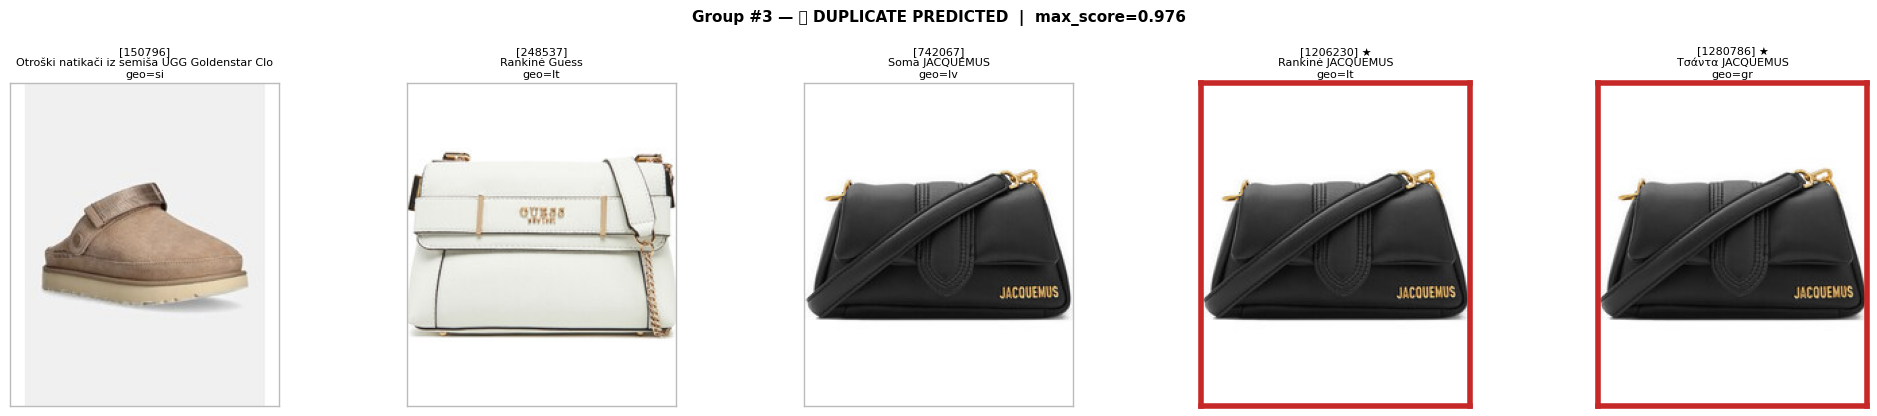

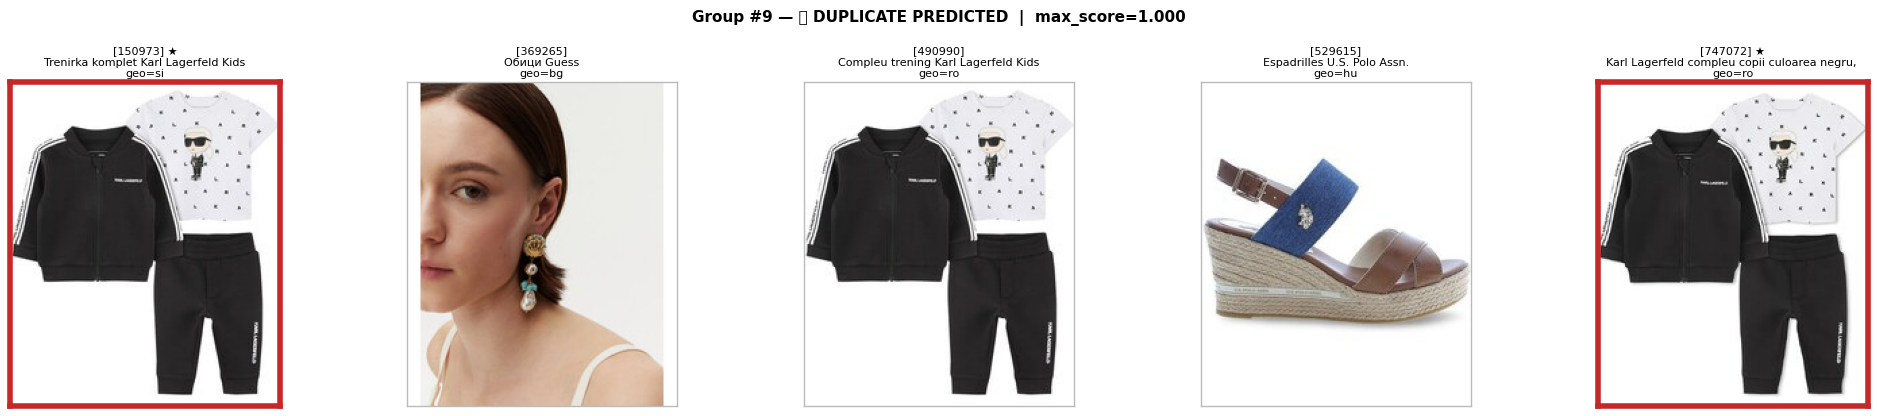

--- 2 predicted NEGATIVE ---


/var/folders/wz/x7xqj0yj6ls_367syhygxjn40000gn/T/ipykernel_44527/3160089666.py:33: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


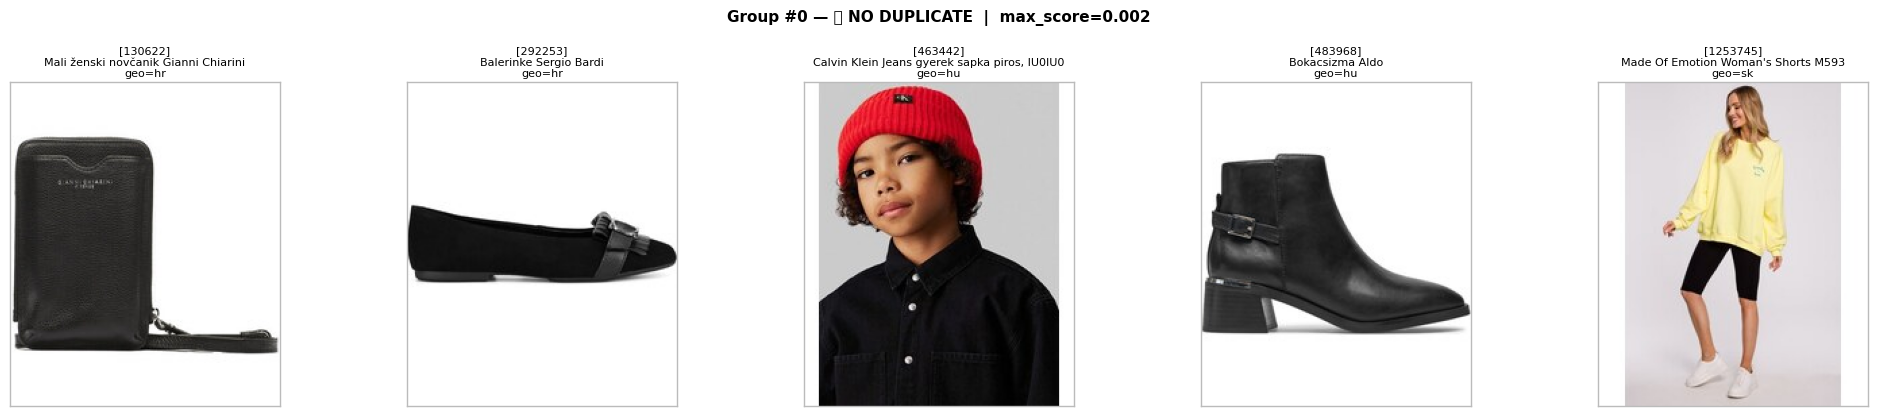

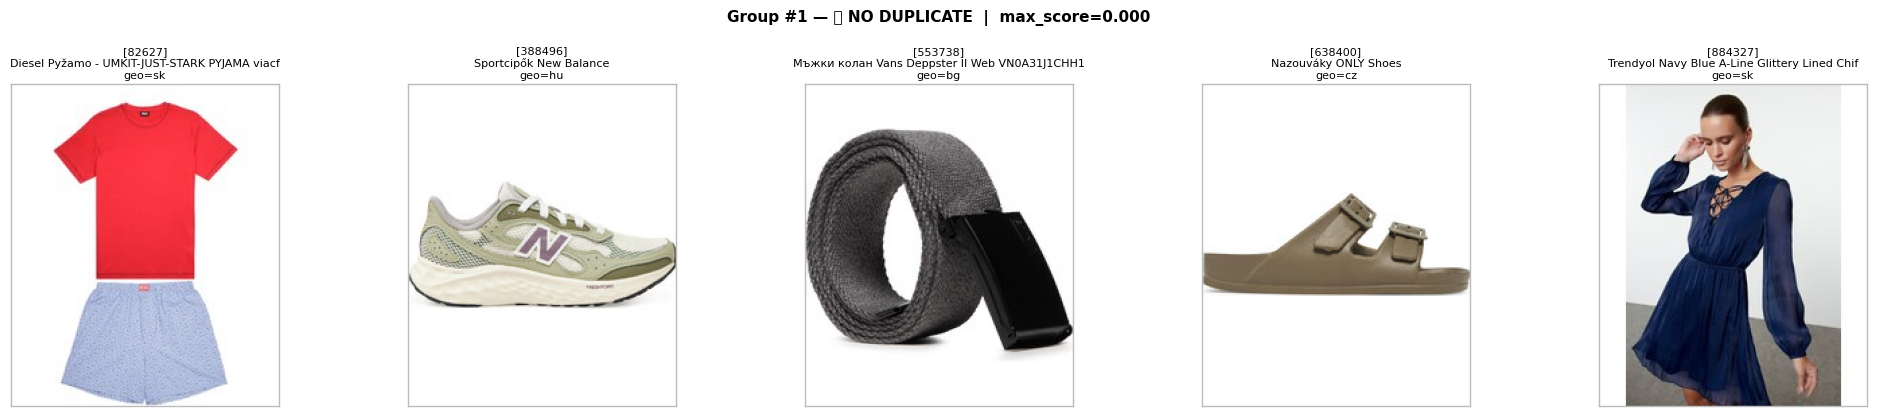

--- 3 DISAGREEMENTS with baseline ---


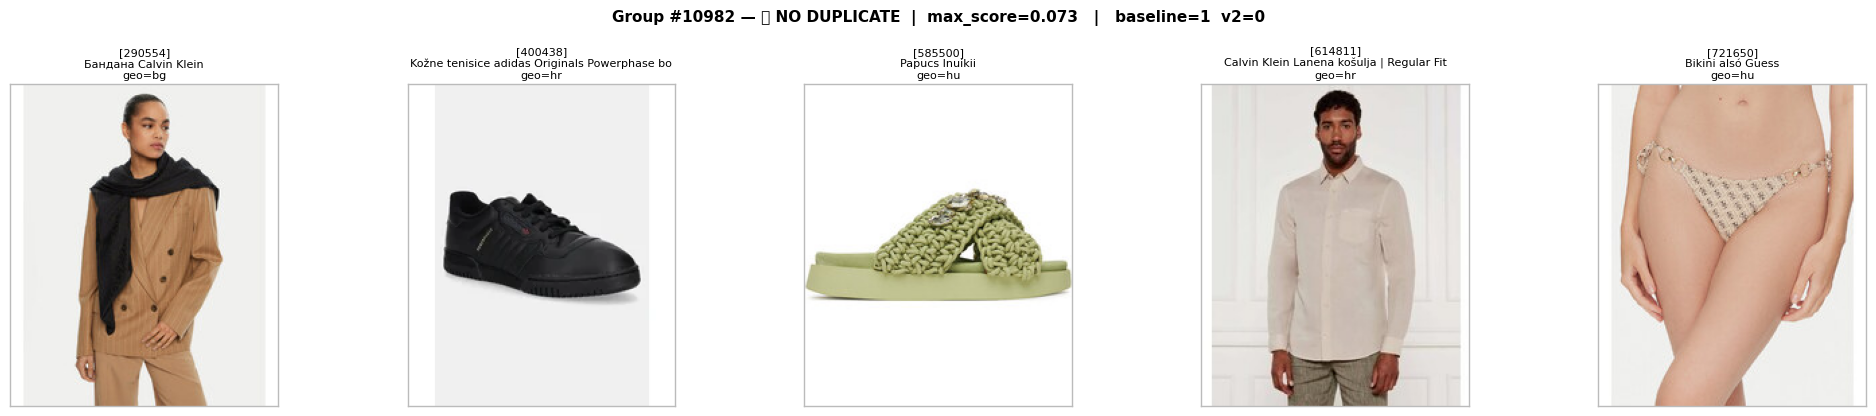

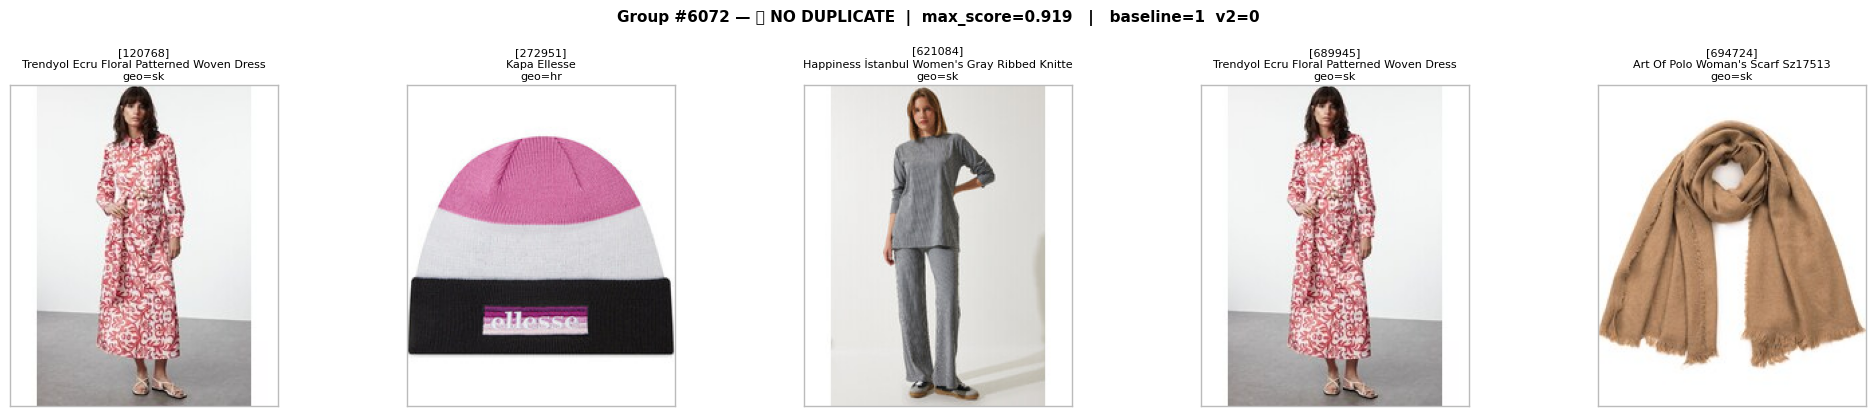

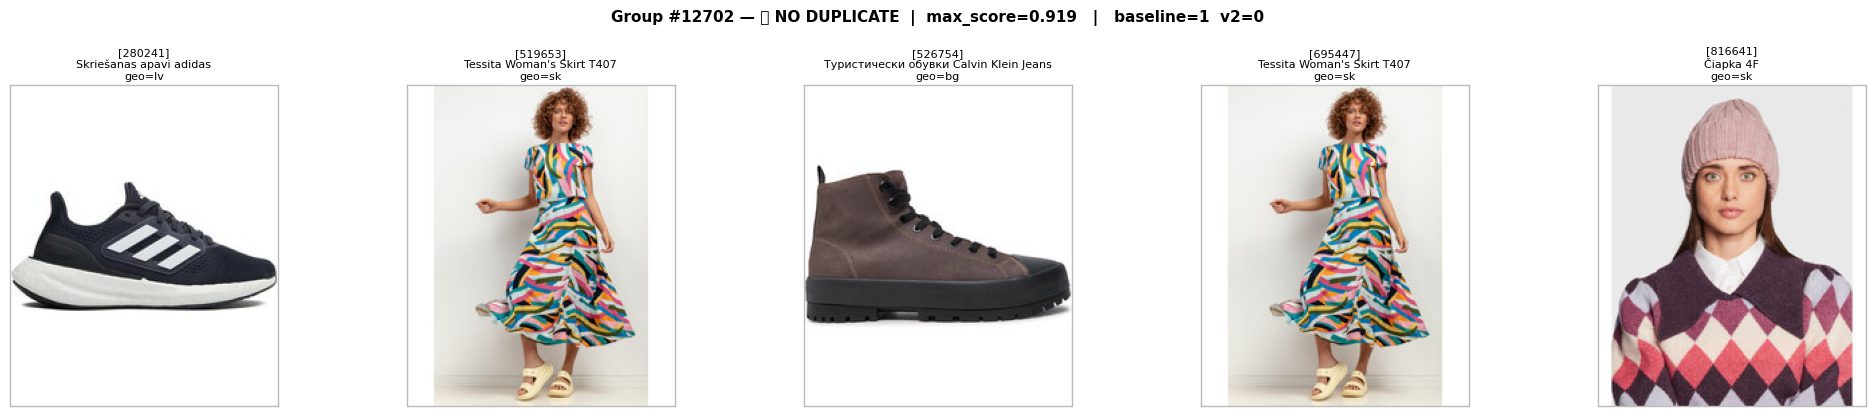

In [16]:
# Visual sanity: 2 predicted-pos + 2 predicted-neg + up to 3 disagreement-with-baseline groups
import matplotlib.patches as mpatches

def show_group(group_idx, header_extra=''):
    row = df_task_1.iloc[group_idx]
    items = [row['item1'], row['item2'], row['item3'], row['item4'], row['item5']]
    pred  = int(row['prediction'])
    score = float(row['max_score'])
    best  = row['best_pair']
    flag  = '🟥 DUPLICATE PREDICTED' if pred == 1 else '🟩 NO DUPLICATE'

    fig, axes = plt.subplots(1, 5, figsize=(20, 4.2))
    for ax, iid in zip(axes, items):
        meta = df_phase1[df_phase1['itemId'] == iid]
        is_best = (best is not None and iid in best and pred == 1)
        try:
            ax.imshow(Image.open(f'{IMAGES_DIR}/{iid}.jpg').convert('RGB'))
        except Exception:
            ax.text(0.5, 0.5, 'no image', ha='center', va='center', transform=ax.transAxes)
            ax.set_facecolor('#eeeeee')
        for sp in ax.spines.values():
            sp.set_edgecolor('#c62828' if is_best else '#bbbbbb')
            sp.set_linewidth(4 if is_best else 1)
        title = ''
        if len(meta):
            t = str(meta.iloc[0].get('title', ''))[:45]; g = meta.iloc[0].get('geo', '?')
            title = f'{t}\ngeo={g}'
        marker = ' ★' if is_best else ''
        ax.set_title(f'[{iid}]{marker}\n{title}', fontsize=8, pad=4)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f'Group #{group_idx} — {flag}  |  max_score={score:.3f}{header_extra}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()

# Need PIL.Image for show_group above
from PIL import Image

pos_idx = df_task_1[df_task_1['prediction'] == 1].index[:2].tolist()
neg_idx = df_task_1[df_task_1['prediction'] == 0].index[:2].tolist()

print('--- 2 predicted POSITIVE ---')
for i in pos_idx: show_group(i)

print('--- 2 predicted NEGATIVE ---')
for i in neg_idx: show_group(i)

if len(disagree_idx) > 0:
    sample = np.random.RandomState(0).choice(disagree_idx, size=min(3, len(disagree_idx)), replace=False)
    print(f'--- 3 DISAGREEMENTS with baseline ---')
    for i in sample:
        old_p = int(old_preds[i]); new_p = int(new_preds[i])
        show_group(int(i), header_extra=f'   |   baseline={old_p}  v2={new_p}')


## 5. Final val measurement

Reload best checkpoint and report a threshold sweep so you can pick the
operating point with the highest val pair-F1. (Reminder: pair-F1 is informational
only — end-to-end clustering F1 in section 6 is the real metric.)


In [17]:
model.load_state_dict(torch.load(SIAMESE_V2_PATH, map_location=device, weights_only=True))
model.eval()

all_logits, all_labels = [], []
with torch.no_grad():
    for it1, it2, lbl in tqdm(val_loader, desc='Val (logits)'):
        it1, it2 = _to_dev(it1, device), _to_dev(it2, device)
        all_logits.append(torch.sigmoid(model(it1, it2)).cpu().numpy())
        all_labels.append(lbl.numpy())

all_probs  = np.concatenate(all_logits)
all_labels = np.concatenate(all_labels).astype(int)

print('threshold |  precision  recall  F1')
print('-' * 42)
best_thr, best_f1 = 0.5, 0.0
for thr in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]:
    preds = (all_probs >= thr).astype(int)
    p = precision_score(all_labels, preds, zero_division=0)
    r = recall_score(all_labels, preds, zero_division=0)
    f = f1_score(all_labels, preds, zero_division=0)
    if f > best_f1:
        best_thr, best_f1 = thr, f
    print(f'  {thr:.2f}    |   {p:.3f}     {r:.3f}    {f:.3f}')
print(f'\nBest threshold: {best_thr}  (val pair-F1={best_f1:.4f})')


Val (logits):   0%|          | 0/782 [00:00<?, ?it/s]

threshold |  precision  recall  F1
------------------------------------------
  0.30    |   0.983     0.985    0.984
  0.40    |   0.986     0.983    0.985
  0.50    |   0.989     0.981    0.985
  0.60    |   0.991     0.977    0.984
  0.70    |   0.993     0.973    0.983
  0.80    |   0.994     0.968    0.981
  0.90    |   0.996     0.956    0.976
  0.95    |   0.997     0.939    0.967

Best threshold: 0.5  (val pair-F1=0.9846)


## 6. End-to-end clustering on the 30k val slice → submission file

Mirrors `phase1/05_phase2_baseline.ipynb`: KNN on joint embeddings → siamese
re-scoring → connected components → write submission. Run this on the val
slice (30k labeled items_train rows) so we have ground truth to verify against
in the next section.


In [20]:
from collections import defaultdict
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# Same val slice construction as phase1/05 (30k items, half from val labels, half noise)
VAL_TOTAL = 30_000

train_label_lookup = dict(zip(df_train['itemId'].astype(str), df_train['label']))
pos_val_pairs      = val_pairs_full[val_pairs_full['is_duplicate'] == 1.0]
pos_item_ids       = set(pos_val_pairs['item_id_1'].astype(str)) | set(pos_val_pairs['item_id_2'].astype(str))
val_label_set      = {train_label_lookup[i] for i in pos_item_ids if i in train_label_lookup}

df_dup_items   = df_train[df_train['label'].isin(val_label_set)]
n_dup          = min(len(df_dup_items), VAL_TOTAL // 2)
n_noise        = VAL_TOTAL - n_dup
df_dup_sample  = df_dup_items.sample(n=n_dup, random_state=42)
df_noise       = df_train[~df_train['label'].isin(val_label_set)].sample(n=n_noise, random_state=42)
df_val_all     = pd.concat([df_dup_sample, df_noise], ignore_index=True)

val_ids_set = set(df_val_all['itemId'].astype(str))
val_labels  = dict(zip(df_val_all['itemId'].astype(str), df_val_all['label']))

df_val_proc = df_train_transformed[df_train_transformed['itemId'].astype(str).isin(val_ids_set)].reset_index(drop=True)
val_item_dataset = LightweightItemDataset(df_val_proc, vocab_manager,
                                          clip_embeddings_dict, text_embeddings_dict)
val_ids = [str(val_item_dataset.df.iloc[i]['itemId']) for i in range(len(val_item_dataset))]
N = len(val_ids)
print(f'Val items: {N:,}  (dup-label: {n_dup:,}  noise: {n_noise:,})')

Val items: 30,000  (dup-label: 15,000  noise: 15,000)


In [21]:
def build_joint_matrix(item_ids, img_dict, txt_dict):
    img_zero = torch.zeros(IMG_EMB_DIM); txt_zero = torch.zeros(TEXT_EMB_DIM)
    rows = [torch.cat([img_dict.get(str(i), img_zero), txt_dict.get(str(i), txt_zero)]) for i in item_ids]
    mat = torch.stack(rows)
    return mat / mat.norm(dim=1, keepdim=True).clamp(min=1e-8)

print('Building joint embedding matrix...')
val_mat = build_joint_matrix(val_ids, clip_embeddings_dict, text_embeddings_dict).to(device)
print(f'  Matrix: {val_mat.shape}')

# Cosine KNN in blocks
KNN_THRESHOLD = 0.60
TOP_K         = 40
BLOCK         = 512

all_i, all_j = [], []
for start in tqdm(range(0, N, BLOCK), desc='KNN'):
    end = min(start + BLOCK, N)
    block = val_mat[start:end]
    sims  = torch.mm(block, val_mat.T)
    for bi in range(end - start):
        sims[bi, start + bi] = -2.0
    vals_k, idx_k = torch.topk(sims, k=TOP_K, dim=1)
    for bi in range(end - start):
        gi = start + bi
        for ki in range(TOP_K):
            gj = idx_k[bi, ki].item()
            if vals_k[bi, ki].item() >= KNN_THRESHOLD and gj > gi:
                all_i.append(gi); all_j.append(gj)

all_i = np.array(all_i, dtype=np.int32)
all_j = np.array(all_j, dtype=np.int32)
print(f'Candidate edges (cos >= {KNN_THRESHOLD}): {len(all_i):,}')


Building joint embedding matrix...
  Matrix: torch.Size([30000, 1024])


KNN:   0%|          | 0/59 [00:00<?, ?it/s]

Candidate edges (cos >= 0.6): 586,696


In [22]:
# Pre-cache features then siamese rescore (much faster than per-edge __getitem__ calls)
KEYS = ['image_embedding','text_embedding','price','geo','colors','departments']
cache = {k: torch.stack([val_item_dataset[i][k] for i in range(N)]) for k in KEYS}

@torch.no_grad()
def score_edges(rows, cols, cache, model, batch=4096):
    out = []
    for s in tqdm(range(0, len(rows), batch), desc='Siamese score'):
        e = min(s + batch, len(rows))
        bi = {k: cache[k][rows[s:e]].to(device) for k in cache}
        bj = {k: cache[k][cols[s:e]].to(device) for k in cache}
        out.append(torch.sigmoid(model(bi, bj)).cpu().numpy())
    return np.concatenate(out)

scores = score_edges(all_i, all_j, cache, model)
print(f'Edge scores: range=[{scores.min():.3f}, {scores.max():.3f}]')


Siamese score:   0%|          | 0/144 [00:00<?, ?it/s]

Edge scores: range=[0.000, 1.000]


In [23]:
# Threshold sweep -> best end-to-end pairwise F1
def evaluate_clustering(id_to_cluster, id_to_label):
    common = list(set(id_to_cluster) & set(id_to_label))
    true_arr = np.array([id_to_label[i]   for i in common])
    pred_arr = np.array([id_to_cluster[i] for i in common])

    def c2(arr):
        _, c = np.unique(arr, return_counts=True)
        return int((c * (c - 1) // 2).sum())

    total_true = c2(true_arr)
    total_pred = c2(pred_arr)
    composite  = np.array([f'{t}|{p}' for t, p in zip(true_arr, pred_arr)])
    tp         = c2(composite)
    fp = total_pred - tp; fn = total_true - tp
    p = tp / max(tp + fp, 1); r = tp / max(tp + fn, 1)
    return p, r, (2 * p * r / max(p + r, 1e-9))

def edges_to_clusters(rows, cols, n, ids):
    if not len(rows):
        return {iid: i for i, iid in enumerate(ids)}
    data = np.ones(2 * len(rows), dtype=np.int8)
    r = np.concatenate([rows, cols]); c = np.concatenate([cols, rows])
    n_comp, lbl = connected_components(csr_matrix((data, (r, c)), shape=(n, n)), directed=False)
    return {ids[i]: int(lbl[i]) for i in range(n)}

print('threshold |  edges    P       R       F1')
print('-' * 50)
best = (0, 0.0, None)
for thr in [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.92, 0.95, 0.97, 0.99]:
    mask = scores >= thr
    er, ec = all_i[mask], all_j[mask]
    id2c = edges_to_clusters(er, ec, N, val_ids)
    p, r, f = evaluate_clustering(id2c, val_labels)
    print(f'  {thr:.2f}    |  {mask.sum():>6,}   {p:.3f}   {r:.3f}   {f:.3f}')
    if f > best[1]:
        best = (thr, f, id2c)

BEST_THR, BEST_F1, BEST_ID2C = best
print(f'\nBest threshold {BEST_THR}  -> end-to-end pairwise F1 = {BEST_F1:.4f}  (baseline ~0.85)')


threshold |  edges    P       R       F1
--------------------------------------------------
  0.50    |  91,331   0.000   0.988   0.000
  0.60    |  86,182   0.000   0.985   0.000
  0.70    |  80,737   0.000   0.983   0.000
  0.80    |  74,339   0.000   0.978   0.000
  0.85    |  70,310   0.000   0.974   0.001
  0.90    |  65,136   0.000   0.965   0.001
  0.92    |  62,338   0.000   0.961   0.001
  0.95    |  56,414   0.000   0.939   0.001
  0.97    |  49,402   0.000   0.896   0.001
  0.99    |  32,183   0.000   0.642   0.001

Best threshold 0.99  -> end-to-end pairwise F1 = 0.0007  (baseline ~0.85)


In [ ]:
# Diagnose: cluster size distribution at the best threshold (pre-chunk)
from collections import Counter
sizes = Counter(BEST_ID2C.values())
size_arr = sorted(sizes.values(), reverse=True)
print(f"Underlying connected components: {len(size_arr):,}")
print(f"  Singletons       : {sum(1 for s in size_arr if s == 1):,}")
print(f"  Multi-item       : {sum(1 for s in size_arr if s > 1):,}")
print(f"  Largest cluster  : {size_arr[0]:,}")
print(f"  Top 10 sizes     : {size_arr[:10]}")

# Pair-count contribution
total_pred_pairs = sum(s * (s - 1) // 2 for s in size_arr)
top1_pairs       = size_arr[0] * (size_arr[0] - 1) // 2
top5_pairs       = sum(s * (s - 1) // 2 for s in size_arr[:5])
print(f"Total predicted pairs : {total_pred_pairs:,}")
print(f"  from top-1 cluster  : {top1_pairs:,}  ({100*top1_pairs/total_pred_pairs:.1f}%)")
print(f"  from top-5 clusters : {top5_pairs:,}  ({100*top5_pairs/total_pred_pairs:.1f}%)")

# True-pair budget for context
from collections import Counter as _C
true_size = _C(val_labels.values())
total_true_pairs = sum(c * (c - 1) // 2 for c in true_size.values())
print(f"Total TRUE pairs in val : {total_true_pairs:,}  (budget for recall)")
print(f"Ratio pred/true         : {total_pred_pairs/max(total_true_pairs,1):.0f}x  (anything >>10x = over-merging)")


In [24]:
# Write the best clustering as a submission file (one cluster per line, ids comma-separated, ≤100/line)
os.makedirs(os.path.dirname(VAL_SUBMISSION), exist_ok=True)

cluster_to_items = defaultdict(list)
for iid, cid in BEST_ID2C.items():
    cluster_to_items[cid].append(iid)

MAX_PER_LINE = 100
lines = []
for members in cluster_to_items.values():
    for s in range(0, len(members), MAX_PER_LINE):
        lines.append(','.join(members[s:s + MAX_PER_LINE]))

with open(VAL_SUBMISSION, 'w') as f:
    f.write('\n'.join(lines))

multi_n = sum(1 for m in cluster_to_items.values() if len(m) > 1)
print(f'Wrote {VAL_SUBMISSION}')
print(f'  Lines: {len(lines):,}  |  Multi-item clusters: {multi_n:,}  |  Singletons: {len(lines) - multi_n:,}')


Wrote /Users/matouskovar/FIT/adm-sp/phase2/submissions/val_clusters_v2.csv
  Lines: 17,193  |  Multi-item clusters: 1,571  |  Singletons: 15,622


## 7. Random cluster sanity check

Reads the submission file we just wrote and shows **one** random multi-item group
each time the cell is re-run. Re-run the cell to draw a different one.

- 🟦 Blue border = anchor (first item in the line)
- 🟢 Green border = same true label as anchor (correct grouping)
- 🔴 Red border = different true label (false positive — over-merged)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image as _PILImage

# Build metadata lookup for the val slice (title, geo, true label)
df_val_meta = df_train[df_train['itemId'].astype(str).isin(val_ids_set)].copy()
df_val_meta['itemId'] = df_val_meta['itemId'].astype(str)
val_meta = df_val_meta.set_index('itemId')[['title','geo','label']].to_dict('index')

# Load the submission file
with open(VAL_SUBMISSION) as f:
    submission_groups = [line.strip().split(',') for line in f if line.strip()]
multi_groups = [g for g in submission_groups if len(g) > 1]

def _img(iid):
    try:
        return _PILImage.open(f'{IMAGES_DIR}/{iid}.jpg').convert('RGB')
    except Exception:
        return None

if not multi_groups:
    print('No multi-item groups in the submission — nothing to show.')
else:
    members      = random.choice(multi_groups)   # fresh draw each time the cell runs
    anchor       = members[0]
    anchor_label = val_meta.get(anchor, {}).get('label')
    member_labels = [val_meta.get(m, {}).get('label') for m in members]
    correct = (len(set(member_labels)) == 1)

    n = len(members)
    fig, axes = plt.subplots(1, n, figsize=(min(4 * n, 22), 5.5))
    if n == 1:
        axes = [axes]
    for ax, iid, lbl in zip(axes, members, member_labels):
        im = _img(iid)
        if im is None:
            ax.text(0.5, 0.5, 'no image', ha='center', va='center', transform=ax.transAxes)
            ax.set_facecolor('#eeeeee')
        else:
            ax.imshow(im)
        if iid == anchor:
            color, lw = '#1565C0', 4
        elif lbl == anchor_label:
            color, lw = '#2e7d32', 3
        else:
            color, lw = '#c62828', 3
        for sp in ax.spines.values():
            sp.set_edgecolor(color); sp.set_linewidth(lw)
        meta = val_meta.get(iid, {})
        ax.set_title(f'[{iid}]\n{str(meta.get("title",""))[:50]}\ngeo={meta.get("geo","?")}  label={lbl}',
                     fontsize=8, pad=4)
        ax.set_xticks([]); ax.set_yticks([])

    flag = 'CORRECT' if correct else 'MIXED (over-merge)'
    fig.suptitle(f'Group of {n}  [{flag}]   anchor_label={anchor_label}'
                 f'   |   {len(multi_groups):,} multi-item groups available — re-run cell to draw another',
                 fontsize=11, fontweight='bold')
    legend = [mpatches.Patch(color='#1565C0', label='Anchor'),
              mpatches.Patch(color='#2e7d32', label='Same true label'),
              mpatches.Patch(color='#c62828', label='Different label (FP)')]
    fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.show()